<a href="https://colab.research.google.com/github/proinvestigadores/Abejas/blob/main/Ambiental_API_vf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Load data**
Mount Google Drive and load the "Coords_Fincas.csv" file into a pandas DataFrame called `df`, displaying the first few rows.


In [ ]:
# Limpiar memoria
%reset -f

# Importar librerías
import pandas as pd
import numpy as np
import requests
import time
from google.colab import drive

# Abrir archivo de datos
drive.mount('/content/drive')
folderpath = '/content/drive/MyDrive/Pigs/Abejas_Monica_Cifuentes/Objetivo_1/Criterio_2_Ambiental/'
filename = 'Coords_Fincas.csv'
df = pd.read_csv(folderpath + filename, sep=";")
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Finca,Latitud,Longitud
0,F1_Jeremías,3.56491,-76.17929
1,F2_Pacho,3.56544,-76.18097
2,F3_Reynel,3.56170,-76.18108
3,F4_Betty,3.55860,-76.17174
4,F5_Magali,3.55823,-76.17803
5,F6_Patrocinio,3.56892,-76.18029
6,F7_Dairo,3.56330,-76.17085
7,F8_Ana,3.56188,-76.17804
8,F9_César,3.57169,-76.18632


# **Define API functions**

## Define api functions
Define the functions `get_elevation`, `get_climate_data`, and `get_soil_data` to fetch data from the respective APIs.


In [ ]:
# Función para obtener elevación desde Open-Elevation API
def get_elevation(lat, lon):
    try:
        response = requests.get(f'https://api.open-elevation.com/api/v1/lookup?locations={lat},{lon}', timeout=10)
        data = response.json()
        return data['results'][0]['elevation']
    except:
        return None

# Función para obtener datos climáticos desde Open-Meteo API
def get_climate_data(lat, lon):
    try:
        # Obtener datos climáticos históricos (promedio últimos 10 años)
        response = requests.get(
            f'https://archive-api.open-meteo.com/v1/archive?'
            f'latitude={lat}&longitude={lon}&start_date=2013-01-01&end_date=2022-12-31&'
            f'daily=temperature_2m_max,temperature_2m_min,precipitation_sum,shortwave_radiation_sum&timezone=auto',
            timeout=15
        )
        data = response.json()

        # Calcular promedios mensuales
        df_climate = pd.DataFrame({
            'date': pd.to_datetime(data['daily']['time']),
            'precipitacion': data['daily']['precipitation_sum'],
            'temp_max': data['daily']['temperature_2m_max'],
            'temp_min': data['daily']['temperature_2m_min'],
            'radiacion': data['daily']['shortwave_radiation_sum']
        })

        # Agrupar por mes y calcular promedios
        monthly_avg = df_climate.groupby(df_climate['date'].dt.month).mean()

        return monthly_avg
    except:
        return None

# Función para obtener datos del suelo desde SoilGrids API con reintentos
def get_soil_data(lat, lon, retries=3):
    for i in range(retries):
        try:
            # Obtener propiedades del suelo
            properties = ['clay', 'silt', 'sand', 'ocd', 'phh2o']
            soil_data = {}

            for prop in properties:
                response = requests.get(
                    f'https://rest.isric.org/soilgrids/v2.0/properties/query?'
                    f'lon={lon}&lat={lat}&property={prop}&depth=0-5cm&value=mean',
                    timeout=15
                )
                if response.status_code == 200:
                    data = response.json()
                    soil_data[prop] = data['properties']['layers'][0]['depths'][0]['values']['mean']
                else:
                    soil_data[prop] = None

            return soil_data
        except:
            time.sleep(3)  # Esperar 2 segundos antes de reintentar
    return None

## Define processing function
Create a function, let's call it `process_fincas_chunk`, that takes a DataFrame chunk as input, iterates through its rows, calls the API functions for each finca, and returns a list of dictionaries containing the collected data.


In [ ]:
def process_fincas_chunk(df_chunk):
    """
    Processes a chunk of finca data, calls API functions for each finca,
    and returns a list of dictionaries with the collected environmental data.

    Args:
        df_chunk: pandas DataFrame containing finca data (Finca, Latitud, Longitud).

    Returns:
        A list of dictionaries, where each dictionary contains environmental
        data for a finca, or an empty list if processing fails or no data is found.
    """
    resultados_chunk = []
    for index, row in df_chunk.iterrows():
        finca_name = row['Finca']
        lat = row['Latitud']
        lon = row['Longitud']

        print(f"Procesando {finca_name}...")

        elevation = get_elevation(lat, lon)
        climate_data = get_climate_data(lat, lon)
        soil_data = get_soil_data(lat, lon)

        finca_data = {
            'Finca': finca_name,
            'Elevacion': elevation,
            'Datos_Climaticos': climate_data.to_dict('list') if climate_data is not None else None,
            'Datos_Suelo': soil_data
        }
        resultados_chunk.append(finca_data)

    return resultados_chunk

# **Process data in parts**

Split the main DataFrame `df` into two halves and store the result.


In [ ]:
# Create parts
df_part1 = df.iloc[:3]
df_part2 = df.iloc[3:6]
df_part3 = df.iloc[6:]

# Call procces for parts
results_1 = process_fincas_chunk(df_part1)
results_1

Procesando F1_Jeremías...
Procesando F2_Pacho...
Procesando F3_Reynel...


[{'Finca': 'F1_Jeremías',
  'Elevacion': 1589.0,
  'Datos_Climaticos': {'date': [Timestamp('2017-07-17 07:12:00'),
    Timestamp('2017-08-17 04:40:51.063829760'),
    Timestamp('2017-09-14 12:00:00'),
    Timestamp('2017-10-15 00:00:00'),
    Timestamp('2017-11-14 12:00:00'),
    Timestamp('2017-12-15 00:00:00'),
    Timestamp('2018-01-14 12:00:00'),
    Timestamp('2018-02-14 12:00:00'),
    Timestamp('2018-03-17 00:00:00'),
    Timestamp('2018-04-16 12:00:00'),
    Timestamp('2018-05-17 00:00:00'),
    Timestamp('2018-06-16 12:00:00')],
   'precipitacion': [18.34774193548387,
    22.575531914893617,
    29.10483870967742,
    30.788333333333334,
    30.497419354838712,
    31.153333333333332,
    27.5941935483871,
    26.36483870967742,
    30.148,
    27.608064516129033,
    18.682666666666666,
    21.223870967741934],
   'temp_max': [20.700967741935486,
    20.77163120567376,
    20.802258064516128,
    20.703,
    20.33225806451613,
    20.332,
    20.43064516129032,
    20.6409677

In [ ]:
print("")
results_2 = process_fincas_chunk(df_part2)
results_2


Procesando F4_Betty...
Procesando F5_Magali...
Procesando F6_Patrocinio...


[{'Finca': 'F4_Betty',
  'Elevacion': 1723.0,
  'Datos_Climaticos': {'date': [Timestamp('2017-07-17 07:12:00'),
    Timestamp('2017-08-17 04:40:51.063829760'),
    Timestamp('2017-09-14 12:00:00'),
    Timestamp('2017-10-15 00:00:00'),
    Timestamp('2017-11-14 12:00:00'),
    Timestamp('2017-12-15 00:00:00'),
    Timestamp('2018-01-14 12:00:00'),
    Timestamp('2018-02-14 12:00:00'),
    Timestamp('2018-03-17 00:00:00'),
    Timestamp('2018-04-16 12:00:00'),
    Timestamp('2018-05-17 00:00:00'),
    Timestamp('2018-06-16 12:00:00')],
   'precipitacion': [32.12129032258065,
    36.19964539007092,
    41.38677419354838,
    46.23233333333334,
    49.939032258064515,
    54.91866666666666,
    51.47838709677419,
    47.81064516129032,
    47.799,
    40.86677419354839,
    28.95,
    35.23129032258065],
   'temp_max': [20.741935483870968,
    20.747517730496455,
    20.754516129032258,
    20.858333333333334,
    20.630967741935486,
    20.65,
    20.794193548387096,
    20.9635483870967

In [ ]:
print("")
results_3 = process_fincas_chunk(df_part3)
results_3


Procesando F7_Dairo...
Procesando F8_Ana...
Procesando F9_César...


[{'Finca': 'F7_Dairo',
  'Elevacion': 1715.0,
  'Datos_Climaticos': {'date': [Timestamp('2017-07-17 07:12:00'),
    Timestamp('2017-08-17 04:40:51.063829760'),
    Timestamp('2017-09-14 12:00:00'),
    Timestamp('2017-10-15 00:00:00'),
    Timestamp('2017-11-14 12:00:00'),
    Timestamp('2017-12-15 00:00:00'),
    Timestamp('2018-01-14 12:00:00'),
    Timestamp('2018-02-14 12:00:00'),
    Timestamp('2018-03-17 00:00:00'),
    Timestamp('2018-04-16 12:00:00'),
    Timestamp('2018-05-17 00:00:00'),
    Timestamp('2018-06-16 12:00:00')],
   'precipitacion': [32.12129032258065,
    36.19964539007092,
    41.38677419354838,
    46.23233333333334,
    49.939032258064515,
    54.91866666666666,
    51.47838709677419,
    47.81064516129032,
    47.799,
    40.86677419354839,
    28.95,
    35.23129032258065],
   'temp_max': [20.741935483870968,
    20.747517730496455,
    20.754516129032258,
    20.858333333333334,
    20.630967741935486,
    20.65,
    20.794193548387096,
    20.9635483870967

# **Abrir dataframe guardado**



In [ ]:
# Guardar nuevo dataframe
# Combine the results from all parths
#resultados_completos = results_1 + results_2 + results_3
#df_diccionario = pd.DataFrame(resultados_completos)
## df_resultados.to_excel(folderpath + 'new.xlsx', index=False)

# Abrir dataframe guardado
df_diccionario = pd.read_excel(folderpath + 'df_diccionario.xlsx')
display(df_diccionario)

,Finca,Elevacion,Datos_Climaticos,Datos_Suelo
0,F1_Jeremías,1589,"{'date': [Timestamp('2017-07-17 07:12:00'), Ti...","{'clay': 356, 'silt': 353, 'sand': 291, 'ocd':..."
1,F2_Pacho,1589,"{'date': [Timestamp('2017-07-17 07:12:00'), Ti...","{'clay': 358, 'silt': 356, 'sand': None, 'ocd'..."
2,F3_Reynel,1551,"{'date': [Timestamp('2017-07-17 07:12:00'), Ti...","{'clay': None, 'silt': 362, 'sand': 286, 'ocd'..."
3,F4_Betty,1723,"{'date': [Timestamp('2017-07-17 07:12:00'), Ti...","{'clay': 339, 'silt': 332, 'sand': 329, 'ocd':..."
4,F5_Magali,1599,"{'date': [Timestamp('2017-07-17 07:12:00'), Ti...","{'clay': 357, 'silt': 357, 'sand': 286, 'ocd':..."
5,F6_Patrocinio,1579,"{'date': [Timestamp('2017-07-17 07:12:00'), Ti...","{'clay': 342, 'silt': 360, 'sand': 298, 'ocd':..."
6,F7_Dairo,1715,"{'date': [Timestamp('2017-07-17 07:12:00'), Ti...","{'clay': 345, 'silt': 315, 'sand': 340, 'ocd':..."
7,F8_Ana,1539,"{'date': [Timestamp('2017-07-17 07:12:00'), Ti...","{'clay': 362, 'silt': 353, 'sand': 285, 'ocd':..."
8,F9_César,1535,"{'date': [Timestamp('2017-07-17 07:12:00'), Ti...","{'clay': 330, 'silt': 374, 'sand': 296, 'ocd':..."


# **Plots: Variables Climáticas**

## Prepare the climate data

Extract the climate data from the `Datos_Climaticos` column and transform it into a suitable format for plotting time series. This will involve normalizing the dates across all fincas and creating a new DataFrame with the climate variables and the corresponding dates.


In [ ]:
import ast
import re
import pandas as pd

# Create an empty list to store processed climate data
processed_climate_data = []

# Iterate through each row of the df_diccionario DataFrame
for index, row in df_diccionario.iterrows():
    finca_name = row['Finca']
    climate_data_str = row['Datos_Climaticos']

    # If 'Datos_Climaticos' is not None, process the data
    if climate_data_str is not None:
        # Replace Timestamp(...) with a string representation before parsing
        climate_data_str = re.sub(r"Timestamp\('(.*?)'\)", r"'\1'", climate_data_str)

        # Safely convert the string to a dictionary
        try:
            climate_data_dict = ast.literal_eval(climate_data_str)
        except (ValueError, SyntaxError):
            print(f"Could not parse climate data for {finca_name}: {climate_data_str}")
            climate_data_dict = None

        if climate_data_dict is not None:
            # Create a temporary DataFrame from the dictionary
            df_temp_climate = pd.DataFrame(climate_data_dict)

            # Ensure the 'date' column is in datetime format, handling mixed formats
            df_temp_climate['date'] = pd.to_datetime(df_temp_climate['date'], format='mixed')

            # Add a 'Finca' column
            df_temp_climate['Finca'] = finca_name

            # Append the temporary DataFrame to the list
            processed_climate_data.append(df_temp_climate)

# Concatenate all the DataFrames in the list into a single DataFrame
df_climate_processed = pd.concat(processed_climate_data, ignore_index=True)

# Sort by 'Finca' and 'date'
df_climate_processed = df_climate_processed.sort_values(by=['Finca', 'date'])

# Display the first few rows and info of the processed DataFrame
display(df_climate_processed)
df_climate_processed.info()

,date,precipitacion,temp_max,temp_min,radiacion,Finca
0,2017-07-17 07:12:00.000000000,18.347742,20.700968,14.690968,16.879419,F1_Jeremías
1,2017-08-17 04:40:51.063829760,22.575532,20.771631,15.262411,16.716312,F1_Jeremías
2,2017-09-14 12:00:00.000000000,29.104839,20.802258,15.459677,16.262839,F1_Jeremías
3,2017-10-15 00:00:00.000000000,30.788333,20.703000,15.626667,15.252133,F1_Jeremías
4,2017-11-14 12:00:00.000000000,30.497419,20.332258,15.337419,14.484290,F1_Jeremías
...,...,...,...,...,...,...
103,2018-02-14 12:00:00.000000000,26.364839,21.093226,14.860323,17.115903,F9_César
104,2018-03-17 00:00:00.000000000,30.148000,21.013333,14.945667,16.925633,F9_César
105,2018-04-16 12:00:00.000000000,27.608065,20.752258,15.441290,15.251839,F9_César
106,2018-05-17 00:00:00.000000000,18.682667,20.637333,15.757333,14.385933,F9_César


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           108 non-null    datetime64[ns]
 1   precipitacion  108 non-null    float64       
 2   temp_max       108 non-null    float64       
 3   temp_min       108 non-null    float64       
 4   radiacion      108 non-null    float64       
 5   Finca          108 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 5.2+ KB


## Times series: climate data
Create time series plots for each climate variable (`precipitacion`, `temp_max`, `temp_min`, `radiacion`) showing the values over time for each finca.


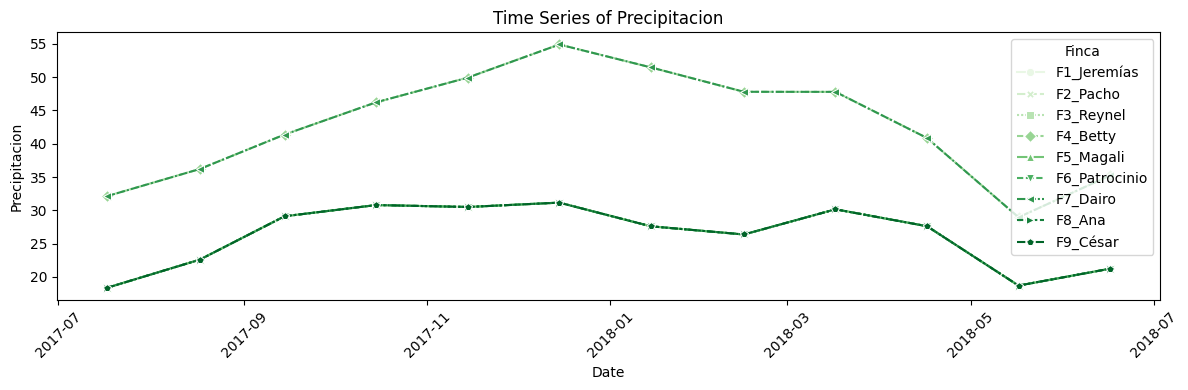

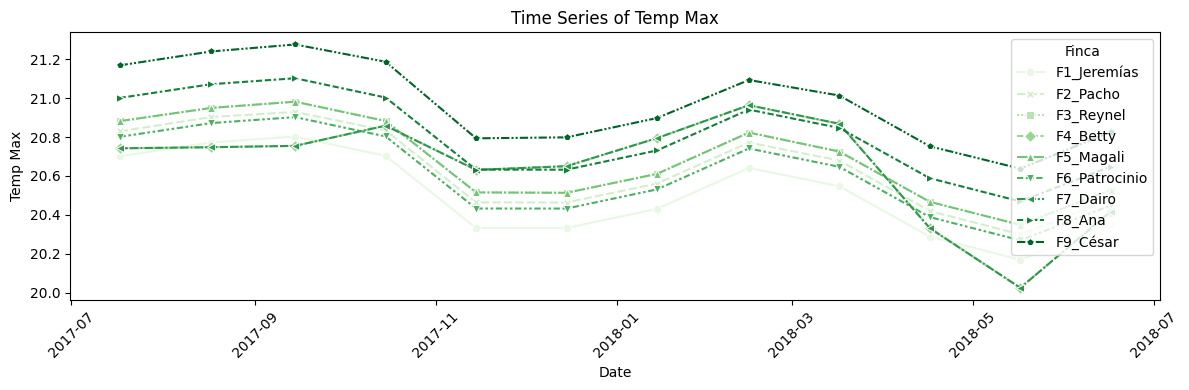

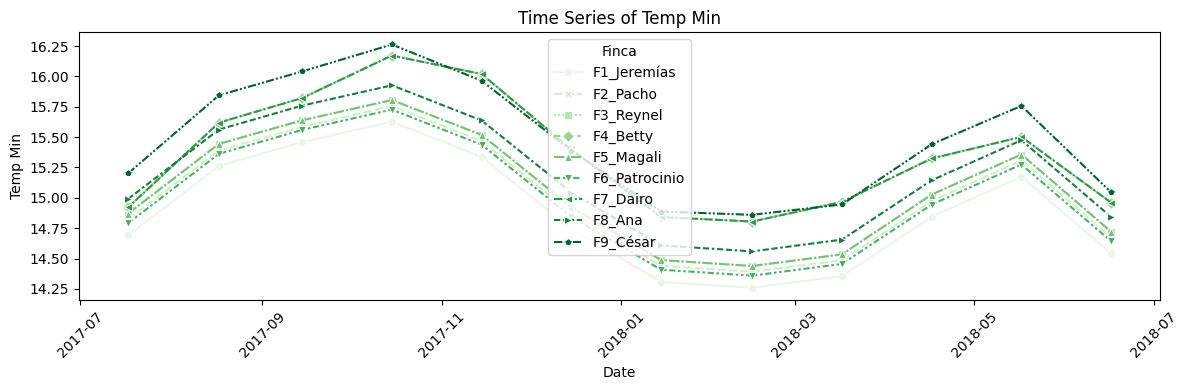

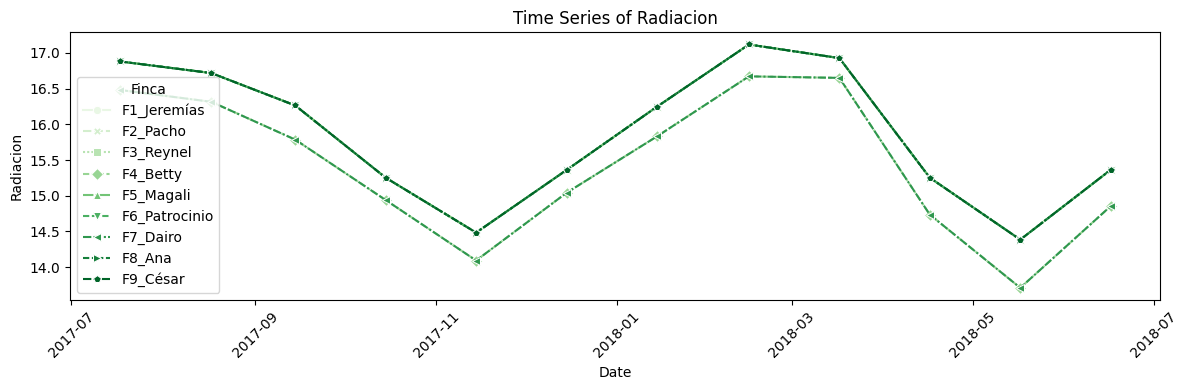

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of climate variables to plot
climate_variables = ['precipitacion', 'temp_max', 'temp_min', 'radiacion']

# Define a green color palette
green_palette = sns.color_palette("Greens", len(df_climate_processed['Finca'].unique()))

# Define a list of markers
markers = ['o', 'X', 's', 'D', '^', 'v', '<', '>', 'p']

# Iterate through each climate variable and create a plot
for variable in climate_variables:
    plt.figure(figsize=(12, 4))
    sns.lineplot(data=df_climate_processed, x='date', y=variable, hue='Finca', palette=green_palette, style='Finca', markers=markers[:len(df_climate_processed['Finca'].unique())])
    plt.title(f'Time Series of {variable.replace("_", " ").title()}')
    plt.xlabel('Date')
    plt.ylabel(variable.replace("_", " ").title())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Boxplots: Climate data
Create boxplots for each climate variable (`precipitacion`, `temp_max`, `temp_min`, `radiacion`) showing the distribution of values for each finca.

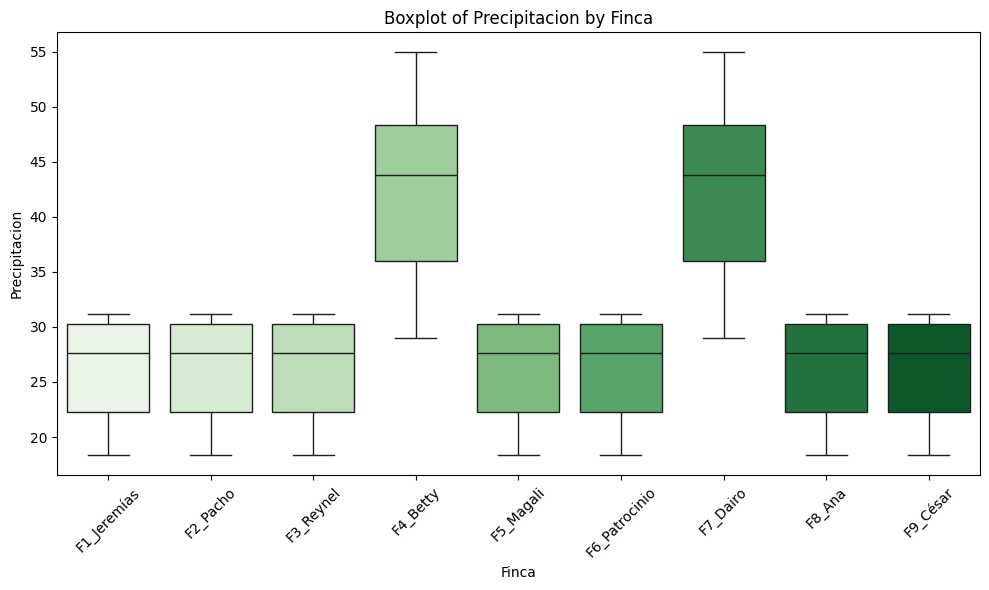

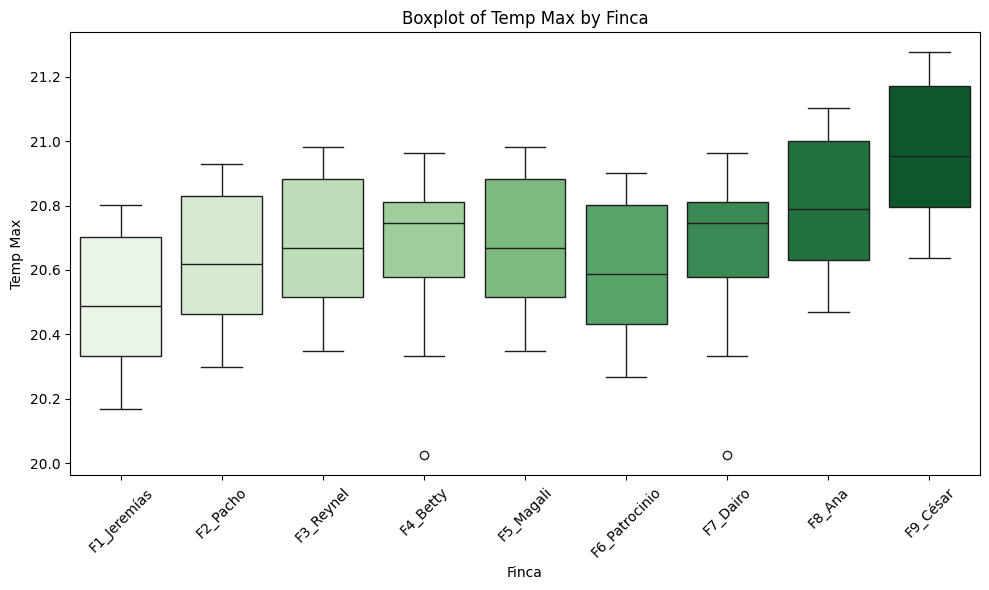

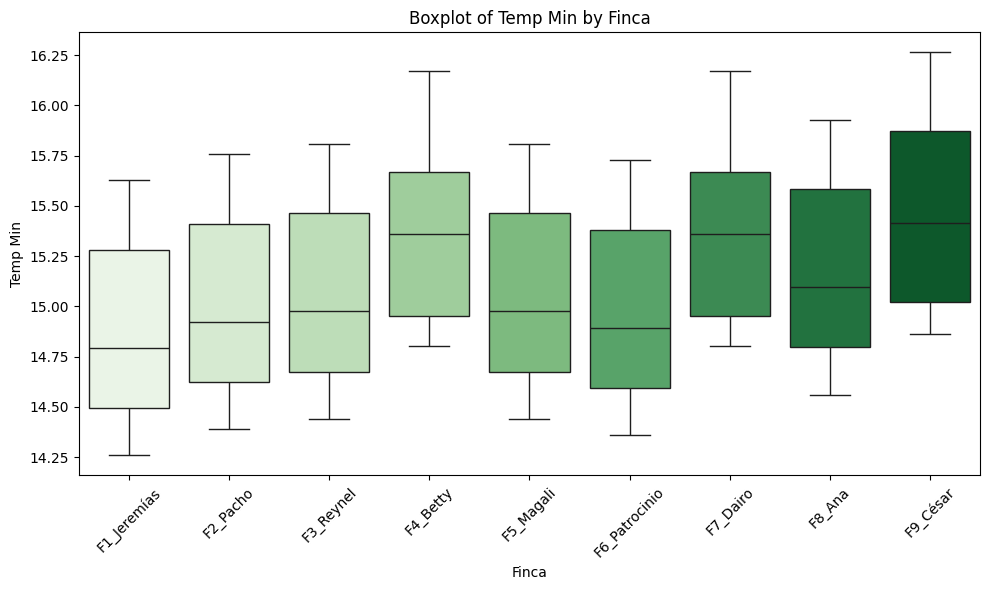

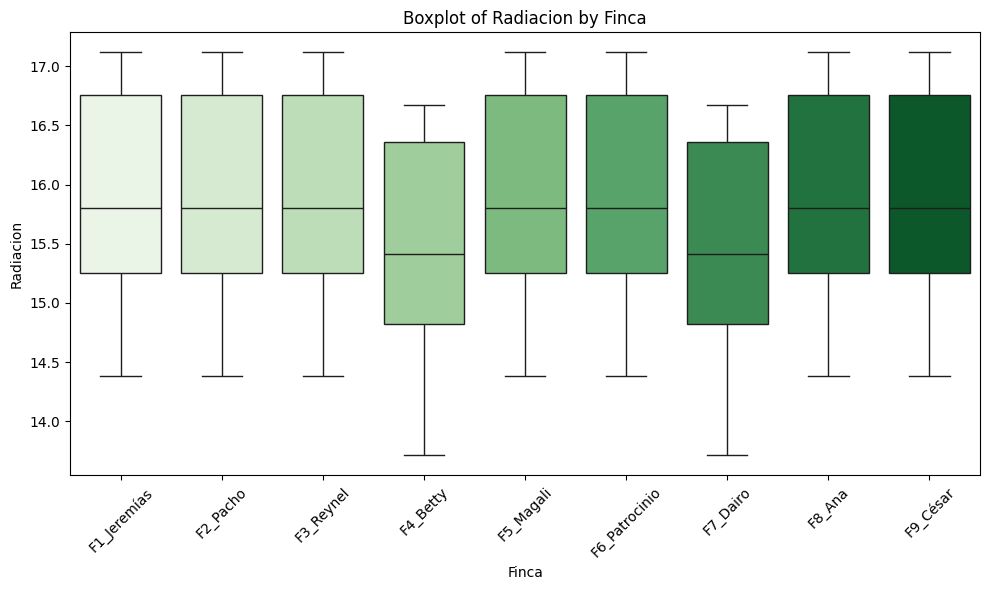

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of climate variables to plot as boxplots
climate_variables = ['precipitacion', 'temp_max', 'temp_min', 'radiacion']

# Define a green color palette
green_palette = sns.color_palette("Greens", len(df_climate_processed['Finca'].unique()))

# Iterate through each climate variable and create a boxplot
for variable in climate_variables:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_climate_processed, x='Finca', y=variable, hue='Finca', palette=green_palette, legend=False)
    plt.title(f'Boxplot of {variable.replace("_", " ").title()} by Finca')
    plt.xlabel('Finca')
    plt.ylabel(variable.replace("_", " ").title())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# **Plots: Variables del Suelo**

## Separate soil dataframe

In [ ]:
import ast

# Create an empty list to store processed soil data
processed_soil_data = []

# Iterate through each row of the df_diccionario DataFrame
for index, row in df_diccionario.iterrows():
    finca_name = row['Finca']
    soil_data_str = row['Datos_Suelo']

    # If 'Datos_Suelo' is not None, process the data
    if soil_data_str is not None:
        # Safely convert the string to a dictionary
        try:
            soil_data_dict = ast.literal_eval(soil_data_str)
        except (ValueError, SyntaxError):
            print(f"Could not parse soil data for {finca_name}: {soil_data_str}")
            soil_data_dict = None

        if soil_data_dict is not None:
            # Add the 'Finca' name to the soil data dictionary
            soil_data_dict['Finca'] = finca_name

            # Append the dictionary to the list
            processed_soil_data.append(soil_data_dict)

# Create a new DataFrame from the list of dictionaries
df_suelo = pd.DataFrame(processed_soil_data)

# Rename columns to Spanish with units
df_suelo = df_suelo.rename(columns={
    'clay': 'Arcilla (g/kg)',
    'silt': 'Limo (g/kg)',
    'sand': 'Arena (g/kg)',
    'ocd': 'Carbono Orgánico (g/kg)',
    'phh2o': 'pH'
})

# Reorder columns to have 'Finca' as the first column
cols = df_suelo.columns.tolist()
cols.insert(0, cols.pop(cols.index('Finca')))
df_suelo = df_suelo[cols]

# Display the new DataFrame
display(df_suelo)

,Finca,Arcilla (g/kg),Limo (g/kg),Arena (g/kg),Carbono Orgánico (g/kg),pH
0,F1_Jeremías,356.0,353,291.0,516,57.0
1,F2_Pacho,358.0,356,NaN,506,54.0
2,F3_Reynel,NaN,362,286.0,502,54.0
3,F4_Betty,339.0,332,329.0,541,52.0
4,F5_Magali,357.0,357,286.0,500,54.0
5,F6_Patrocinio,342.0,360,298.0,522,NaN
6,F7_Dairo,345.0,315,340.0,557,53.0
7,F8_Ana,362.0,353,285.0,503,56.0
8,F9_César,330.0,374,296.0,498,55.0


##Plot soil variables by Finca

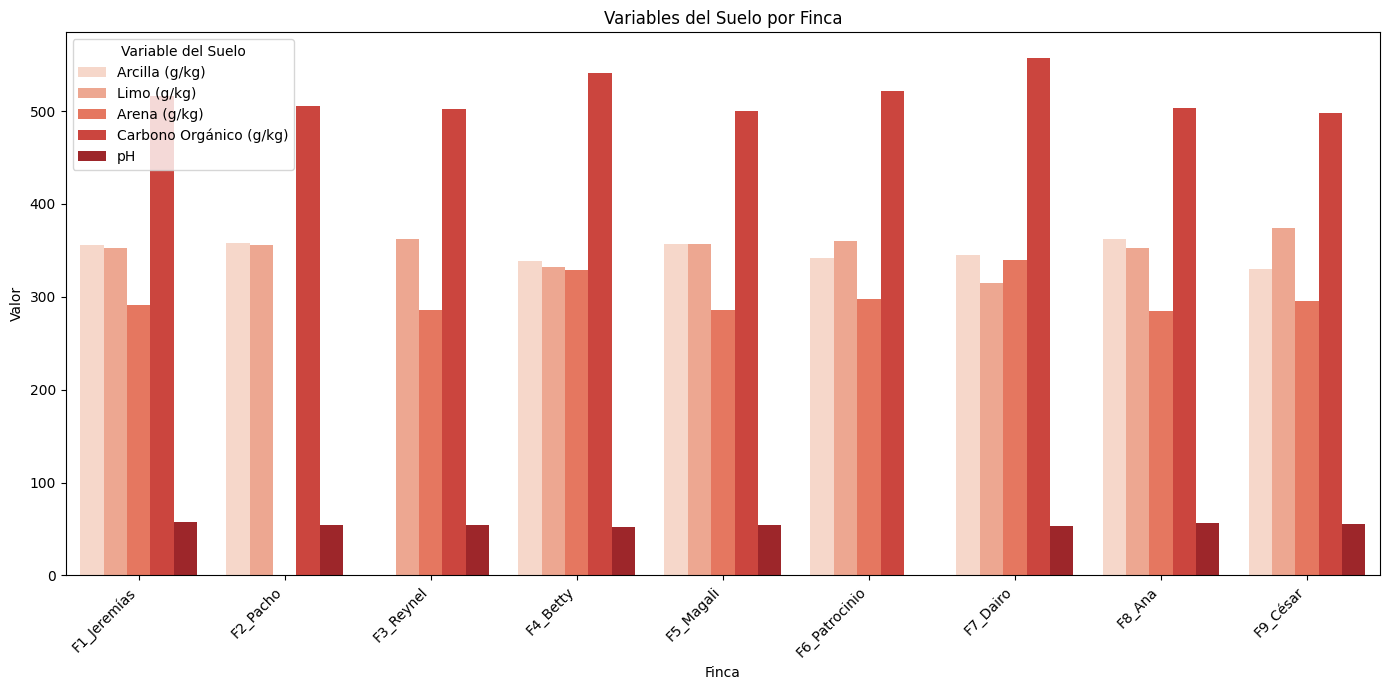

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for plotting
df_suelo_melted = df_suelo.melt(id_vars='Finca', var_name='Variable del Suelo', value_name='Valor')

# Create a single grouped bar plot
plt.figure(figsize=(14, 7))
sns.barplot(data=df_suelo_melted, x='Finca', y='Valor', hue='Variable del Suelo', palette='Reds')
plt.title('Variables del Suelo por Finca')
plt.xlabel('Finca')
plt.ylabel('Valor')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **Contraste estadístico**

# Task
Perform statistical contrasts between fincas for the climate variables in the "df_diccionario" dataframe. Use appropriate statistical tests (parametric or non-parametric) and interpret the results, presenting them in tables and/or graphs.

## Check assumptions for parametric tests (optional but recommended)

### Subtask:
Check assumptions for parametric tests (optional but recommended)


**Reasoning**:
Perform normality and homogeneity of variance tests for each climate variable and interpret the results.



In [ ]:
from scipy import stats

climate_variables = ['precipitacion', 'temp_max', 'temp_min', 'radiacion']
normality_results = {}
homogeneity_results = {}

# Normality test (Shapiro-Wilk) for each finca per variable
print("--- Normality Test (Shapiro-Wilk) ---")
for variable in climate_variables:
    normality_results[variable] = {}
    print(f"\nVariable: {variable.replace('_', ' ').title()}")
    for finca in df_climate_processed['Finca'].unique():
        data = df_climate_processed[df_climate_processed['Finca'] == finca][variable].dropna()
        if len(data) >= 3: # Shapiro-Wilk requires at least 3 data points
            statistic, p_value = stats.shapiro(data)
            normality_results[variable][finca] = {'statistic': statistic, 'p_value': p_value}
            alpha = 0.05
            print(f"  Finca: {finca}, Statistic: {statistic:.4f}, P-value: {p_value:.4f} ({'Normal' if p_value > alpha else 'Not Normal'})")
        else:
            print(f"  Finca: {finca}, Not enough data for normality test (requires >= 3)")
            normality_results[variable][finca] = {'statistic': None, 'p_value': None}


# Homogeneity of variances test (Levene's) across all fincas per variable
print("\n--- Homogeneity of Variances Test (Levene's) ---")
for variable in climate_variables:
    data_groups = [df_climate_processed[df_climate_processed['Finca'] == finca][variable].dropna() for finca in df_climate_processed['Finca'].unique()]
    # Filter out empty groups or groups with insufficient data
    data_groups = [group for group in data_groups if len(group) > 0]

    if len(data_groups) >= 2: # Levene's test requires at least two groups
        statistic, p_value = stats.levene(*data_groups)
        homogeneity_results[variable] = {'statistic': statistic, 'p_value': p_value}
        alpha = 0.05
        print(f"Variable: {variable.replace('_', ' ').title()}, Statistic: {statistic:.4f}, P-value: {p_value:.4f} ({'Equal Variances' if p_value > alpha else 'Unequal Variances'})")
    else:
        print(f"Variable: {variable.replace('_', ' ').title()}, Not enough groups for homogeneity test (requires >= 2)")
        homogeneity_results[variable] = {'statistic': None, 'p_value': None}

# Determine appropriate test based on assumptions
print("\n--- Test Appropriateness ---")
for variable in climate_variables:
    print(f"\nVariable: {variable.replace('_', ' ').title()}")
    all_normal = all(result['p_value'] > 0.05 for result in normality_results[variable].values() if result['p_value'] is not None)
    equal_variances = homogeneity_results[variable]['p_value'] is not None and homogeneity_results[variable]['p_value'] > 0.05

    if all_normal and equal_variances:
        print("  Assumptions for parametric test (ANOVA) met.")
    elif all_normal and not equal_variances:
         print("  Data is normal but variances are unequal. Consider Welch's ANOVA (parametric) or a non-parametric test.")
    else:
        print("  Normality assumption not met for at least one finca. Non-parametric test (Kruskal-Wallis) is recommended.")

--- Normality Test (Shapiro-Wilk) ---

Variable: Precipitacion
  Finca: F1_Jeremías, Statistic: 0.8672, P-value: 0.0602 (Normal)
  Finca: F2_Pacho, Statistic: 0.8672, P-value: 0.0602 (Normal)
  Finca: F3_Reynel, Statistic: 0.8672, P-value: 0.0602 (Normal)
  Finca: F4_Betty, Statistic: 0.9563, P-value: 0.7307 (Normal)
  Finca: F5_Magali, Statistic: 0.8672, P-value: 0.0602 (Normal)
  Finca: F6_Patrocinio, Statistic: 0.8672, P-value: 0.0602 (Normal)
  Finca: F7_Dairo, Statistic: 0.9563, P-value: 0.7307 (Normal)
  Finca: F8_Ana, Statistic: 0.8672, P-value: 0.0602 (Normal)
  Finca: F9_César, Statistic: 0.8672, P-value: 0.0602 (Normal)

Variable: Temp Max
  Finca: F1_Jeremías, Statistic: 0.9217, P-value: 0.3002 (Normal)
  Finca: F2_Pacho, Statistic: 0.9199, P-value: 0.2847 (Normal)
  Finca: F3_Reynel, Statistic: 0.9216, P-value: 0.2993 (Normal)
  Finca: F4_Betty, Statistic: 0.8799, P-value: 0.0874 (Normal)
  Finca: F5_Magali, Statistic: 0.9216, P-value: 0.2993 (Normal)
  Finca: F6_Patrocinio

## Perform statistical tests

Apply appropriate statistical tests (e.g., ANOVA for parametric, Kruskal-Wallis for non-parametric) to compare each climate variable across the different fincas.


In [ ]:
from scipy.stats import f_oneway, kruskal

# Dictionary to store test results
statistical_test_results = {}

# Perform ANOVA for variables where assumptions were met
anova_variables = ['temp_max', 'temp_min', 'radiacion']
for variable in anova_variables:
    data_groups = [df_climate_processed[df_climate_processed['Finca'] == finca][variable].dropna() for finca in df_climate_processed['Finca'].unique()]
    # Filter out empty groups or groups with insufficient data
    data_groups = [group for group in data_groups if len(group) > 0]
    if len(data_groups) >= 2:
        statistic, p_value = f_oneway(*data_groups)
        statistical_test_results[variable] = {'test': 'ANOVA', 'statistic': statistic, 'p_value': p_value}
    else:
         statistical_test_results[variable] = {'test': 'ANOVA', 'statistic': None, 'p_value': None}


# Perform Kruskal-Wallis test for 'precipitacion'
variable = 'precipitacion'
data_groups = [df_climate_processed[df_climate_processed['Finca'] == finca][variable].dropna() for finca in df_climate_processed['Finca'].unique()]
# Filter out empty groups or groups with insufficient data
data_groups = [group for group in data_groups if len(group) > 0]
if len(data_groups) >= 2:
    statistic, p_value = kruskal(*data_groups)
    statistical_test_results[variable] = {'test': 'Kruskal-Wallis', 'statistic': statistic, 'p_value': p_value}
else:
    statistical_test_results[variable] = {'test': 'Kruskal-Wallis', 'statistic': None, 'p_value': None}


# Display the results
print("Statistical Test Results:")
for variable, result in statistical_test_results.items():
    print(f"Variable: {variable.replace('_', ' ').title()}")
    print(f"  Test: {result['test']}")
    print(f"  Statistic: {result['statistic']:.4f}" if result['statistic'] is not None else "  Statistic: N/A")
    print(f"  P-value: {result['p_value']:.4f}" if result['p_value'] is not None else "  P-value: N/A")
    alpha = 0.05
    if result['p_value'] is not None:
        print(f"  Conclusion: {'Significant difference between fincas' if result['p_value'] < alpha else 'No significant difference between fincas'}")
    else:
        print("  Conclusion: Cannot perform test due to insufficient data")


Statistical Test Results:
Variable: Temp Max
  Test: ANOVA
  Statistic: 4.0931
  P-value: 0.0003
  Conclusion: Significant difference between fincas
Variable: Temp Min
  Test: ANOVA
  Statistic: 2.1422
  P-value: 0.0386
  Conclusion: Significant difference between fincas
Variable: Radiacion
  Test: ANOVA
  Statistic: 0.4555
  P-value: 0.8843
  Conclusion: No significant difference between fincas
Variable: Precipitacion
  Test: Kruskal-Wallis
  Statistic: 48.2045
  P-value: 0.0000
  Conclusion: Significant difference between fincas


## Interpret results

### Subtask:
Interpret the p-values obtained from the statistical tests to determine if there are statistically significant differences in climate variables between fincas.


In [ ]:
# Set the significance level
alpha = 0.05

# Iterate through the statistical test results and interpret the p-values
print("Statistical Test Interpretation:")
for variable, result in statistical_test_results.items():
    print(f"\nVariable: {variable.replace('_', ' ').title()}")
    if result['p_value'] is not None:
        print(f"  Test: {result['test']}")
        print(f"  P-value: {result['p_value']:.4f}")
        if result['p_value'] < alpha:
            print(f"  Interpretation: Since the p-value ({result['p_value']:.4f}) is less than alpha ({alpha}), there is a statistically significant difference in {variable.replace('_', ' ').title()} between the fincas.")
        else:
            print(f"  Interpretation: Since the p-value ({result['p_value']:.4f}) is greater than or equal to alpha ({alpha}), there is no statistically significant difference in {variable.replace('_', ' ').title()} between the fincas.")
    else:
        print("  Interpretation: Test could not be performed due to insufficient data.")


Statistical Test Interpretation:

Variable: Temp Max
  Test: ANOVA
  P-value: 0.0003
  Interpretation: Since the p-value (0.0003) is less than alpha (0.05), there is a statistically significant difference in Temp Max between the fincas.

Variable: Temp Min
  Test: ANOVA
  P-value: 0.0386
  Interpretation: Since the p-value (0.0386) is less than alpha (0.05), there is a statistically significant difference in Temp Min between the fincas.

Variable: Radiacion
  Test: ANOVA
  P-value: 0.8843
  Interpretation: Since the p-value (0.8843) is greater than or equal to alpha (0.05), there is no statistically significant difference in Radiacion between the fincas.

Variable: Precipitacion
  Test: Kruskal-Wallis
  P-value: 0.0000
  Interpretation: Since the p-value (0.0000) is less than alpha (0.05), there is a statistically significant difference in Precipitacion between the fincas.


## Present results

### Subtask:
Present the results of the statistical tests in a clear and organized manner, potentially using tables or visualizations if appropriate.


**Reasoning**:
Create a pandas DataFrame from the statistical test results dictionary and format it for display.



In [ ]:
# Create a DataFrame from the results
df_test_results = pd.DataFrame.from_dict(statistical_test_results, orient='index')

# Rename columns
df_test_results = df_test_results.rename(columns={
    'test': 'Test Performed',
    'statistic': 'Statistic',
    'p_value': 'P-value'
})

# Format 'Statistic' and 'P-value' columns
df_test_results['Statistic'] = df_test_results['Statistic'].apply(lambda x: f'{x:.4f}' if pd.notnull(x) else 'N/A')
df_test_results['P-value'] = df_test_results['P-value'].apply(lambda x: f'{x:.4f}' if pd.notnull(x) else 'N/A')

# Display the DataFrame
display(df_test_results)

,Test Performed,Statistic,P-value
temp_max,ANOVA,4.0931,0.0003
temp_min,ANOVA,2.1422,0.0386
radiacion,ANOVA,0.4555,0.8843
precipitacion,Kruskal-Wallis,48.2045,0.0000


## Summary:

### Data Analysis Key Findings

*   **Normality and Homogeneity of Variances:**
    *   'Temp Max', 'Temp Min', and 'Radiacion' data are normally distributed and have equal variances across fincas.
    *   'Precipitacion' data is normally distributed but has unequal variances across fincas.
*   **Statistical Significance:**
    *   There is a statistically significant difference between fincas for 'Temp Max' (ANOVA p-value = 0.0003), 'Temp Min' (ANOVA p-value = 0.0386), and 'Precipitacion' (Kruskal-Wallis p-value = 0.0000).
    *   There is no statistically significant difference between fincas for 'Radiacion' (ANOVA p-value = 0.8843).

### Insights or Next Steps

*   For the variables with significant differences ('Temp Max', 'Temp Min', and 'Precipitacion'), further post-hoc tests (e.g., Tukey's HSD for ANOVA, Dunn's test for Kruskal-Wallis) could be performed to identify which specific fincas differ from each other.
*   Visualize the distribution of 'Temp Max', 'Temp Min', and 'Precipitacion' across fincas (e.g., using box plots) to visually represent the identified differences.


In [ ]:
import pandas as pd

# Prepare data for normality test results table
normality_data = []
alpha = 0.05

for variable, results_by_finca in normality_results.items():
    for finca, result in results_by_finca.items():
        statistic = result['statistic']
        p_value = result['p_value']
        conclusion = 'N/A (Insufficient Data)'
        if p_value is not None:
            conclusion = 'Normal' if p_value > alpha else 'Not Normal'

        normality_data.append({
            'Variable': variable.replace('_', ' ').title(),
            'Finca': finca,
            'Statistic': f'{statistic:.4f}' if statistic is not None else 'N/A',
            'P-value': f'{p_value:.4f}' if p_value is not None else 'N/A',
            'Conclusion': conclusion
        })

df_normality_results = pd.DataFrame(normality_data)

# Display the table
print("--- Normality Test (Shapiro-Wilk) Results ---")
display(df_normality_results)

--- Normality Test (Shapiro-Wilk) Results ---


,Variable,Finca,Statistic,P-value,Conclusion
0,Precipitacion,F1_Jeremías,0.8672,0.0602,Normal
1,Precipitacion,F2_Pacho,0.8672,0.0602,Normal
2,Precipitacion,F3_Reynel,0.8672,0.0602,Normal
3,Precipitacion,F4_Betty,0.9563,0.7307,Normal
4,Precipitacion,F5_Magali,0.8672,0.0602,Normal
5,Precipitacion,F6_Patrocinio,0.8672,0.0602,Normal
6,Precipitacion,F7_Dairo,0.9563,0.7307,Normal
7,Precipitacion,F8_Ana,0.8672,0.0602,Normal
8,Precipitacion,F9_César,0.8672,0.0602,Normal
9,Temp Max,F1_Jeremías,0.9217,0.3002,Normal
